<a href="https://colab.research.google.com/github/GenerationBR/WebScraping-e-Matplotlib/blob/main/Data_Analyisis_WebScraping_e_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# para o trabalho com coleta de informações
# 1 - entrada manual - usuario informa dados
# 2 - raspagem de dados - web scraping - entra em um site e coleta seus dados
# 3 - importação/automação de dados - sensores, apis, processos de fabrica...

# vamos usar web scraping para coletar dados de noticias
import requests # para a API
import pandas as pd # para deixar em formato legível de dado
# se colocar import no debaixo, vai sobrecarregar o sistema, então usamos from
# para especificar a função
# para puxar uma função especifica de uma biblioteca, não precisamos dela toda
# from [BIBLIOTECA] import [FUNÇÃO]
from datetime import datetime

# temos que importar uma biblioteca de web scraping
from bs4 import BeautifulSoup

In [ ]:
# vamos criar a função para coletar os dados do site alvo
def coletar_noticias_g1():
  url_g1 = 'https://g1.globo.com/'

  # vamos usar um agente para que o site não bloqueie a nossa requisição
  headers = {
      'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36'
  }

  # agora vamos condicionar nosso uso
  # try - except (o substituto do if-else)
  # try """=""" if status.code == 200

  try:
    resposta = requests.get(url_g1, headers=headers)
    # eu quero verificar se deu tudo certo, como se eu tiesse usado status code
    resposta.raise_for_status()

    # vou conectar o web scrap para coletar os dados para nós
    # variavel = chama a biblioteca(método que armazena(response.text), atributo de coleta)
    soup = BeautifulSoup(resposta.text, 'html.parser')

    # de onde vamos pegar as informações
    # comando find.all - enconte tudo('a', class_='feed-post-link') - encontre tudo

    # tags - p - texto paragrafo
    # a - link
    # img - imagem
    # h1, h2, h3 - cabeçalhos
    # video
    posts = soup.find_all('a', class_='feed-post-link')

    lista_noticias = []

    for i in posts:
      titulo = i.get_text()
      link = i.get('href')
      lista_noticias.append({'Titulo':titulo,
                             'Link':link,
                             'Data':datetime.now().strftime('%d/%m/%y')})

    df_noticias = pd.DataFrame(lista_noticias)

      # dentro do try, para mostrar os dados sempre é legal trazer o return
    return df_noticias
  except Exception as e:
    print('Não consegui ler as noticias')
    return None

In [ ]:
noticias = coletar_noticias_g1()
if noticias is not None:
  display(noticias.head(10))

,Titulo,Link,Data
0,"Aumento de capital pressiona caixa do DF, que ...",https://g1.globo.com/economia/blog/ana-flor/po...,22/04/26
1,Toffoli se declara suspeito para julgar prisão...,https://g1.globo.com/df/distrito-federal/notic...,22/04/26
2,Candidata a miss morre ao cair de apartamento;...,https://g1.globo.com/rj/rio-de-janeiro/noticia...,22/04/26
3,Empresário é morto a tiros durante abordagem d...,https://g1.globo.com/rj/rio-de-janeiro/noticia...,22/04/26
4,Irã diz que apreendeu 2 navios após Trump este...,https://g1.globo.com/mundo/ao-vivo/eua-ataque-...,22/04/26
5,"'Cale a boca, Trump': Irã zomba de extensão de...",https://g1.globo.com/mundo/noticia/2026/04/22/...,22/04/26
6,Entenda a liberação de Ramagem nos EUA e a exp...,https://g1.globo.com/politica/noticia/2026/04/...,22/04/26
7,"Novo Minha Casa, Minha Vida passa a valer hoje...",https://g1.globo.com/economia/noticia/2026/04/...,22/04/26


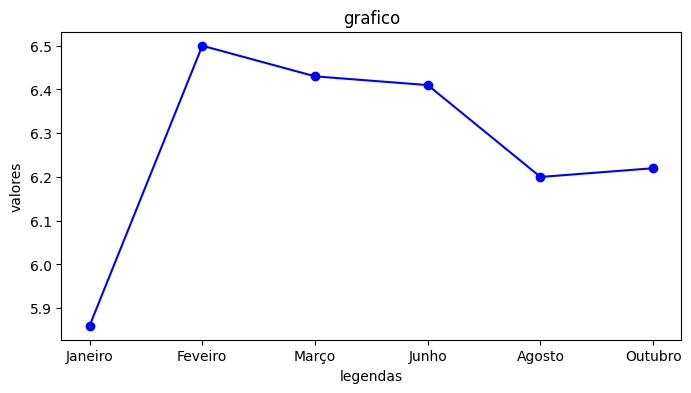

In [ ]:
# vamos criar um grafico com o valor médio da gasolina mês a mês em 2025

# para fazer um gráfico precisamos de, pelo menos, dois eixos
x_mes = ['Janeiro', 'Feveiro', 'Março', 'Junho', 'Agosto', 'Outubro']
# precisamos de um eixo de legenda e um eixo de valor, pelo menos
y_preco = [5.86, 6.50, 6.43, 6.41, 6.20, 6.22]

# a biblioteca que gera graficos é a matplotlib ou potly

# com matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4)) # dimensionamento da imagem - opcional

# para gerar o gráfico
# plt.plot(eixo x, eixo y, marker='o', color='COR EM INGLES')
plt.plot(x_mes, y_preco, marker='o', color='blue')

# se quiser titulo
plt.title('grafico')

#nomear os eixos
plt.xlabel('legendas')
plt.ylabel('valores')

#para mostrar
plt.show()